Predict Restaurant Rating

In [8]:
import pandas as pd
import matplotlib.pyplot as plt



Loding Dataset

In [9]:
df=pd.read_csv('Dataset .csv')
df.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314


here i used relative path of data set

In [10]:
from sklearn.model_selection import train_test_split

Splitting the data into train and test datasets

In [11]:
x_val=['City','Cuisines','Has Table booking','Has Online delivery','Price range','Votes','Average Cost for two','Rating color','Rating text']
X=df[x_val]
 # X must be 2D (takes no of samples, takes no of fetures)
y=df['Aggregate rating']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Preprocessing the dataset by handling missing values
and encoding categorical variables.

In [12]:
from sklearn.impute import SimpleImputer 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [13]:

num_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])
cat_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(drop='first', handle_unknown='ignore'))
])
preprocessor=ColumnTransformer(transformers=[
    ('num',num_pipeline,['Votes','Price range','Average Cost for two']),
            ('cat',cat_pipeline,['City','Cuisines','Has Table booking','Has Online delivery','Rating color','Rating text'])
])

In [14]:
from sklearn.linear_model import LinearRegression

Training Linear Regression model on thetraining data.

In [15]:
model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])


model.fit(X_train,y_train)
model.predict(X_test)
print(model.score(X_test,y_test))

0.9847648846987671


C:\Users\Ram\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\Ram\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

Evaluate the model's performance using appropriate
regression metrics (mean squared error, R-squared)
on the testing data.

In [17]:

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)


Mean Squared Error (MSE): 0.03467678290553769
R-squared (R²): 0.9847648846987671


C:\Users\Ram\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Extracting and Analyzing Feature Importance from the Logistic Regression Model

In [18]:
regressor = model.named_steps['regressor'] 
preprocessor = model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
coefficients = regressor.coef_

import pandas as pd
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                                                Feature  Coefficient
1675                         cat__Rating text_Excellent     1.357276
1546   cat__Cuisines_Seafood, Filipino, Asian, European     0.476460
1679                         cat__Rating text_Very Good     0.454637
1670                            cat__Rating color_Green     0.454637
1150      cat__Cuisines_Mexican, American, Healthy Food     0.438496
...                                                 ...          ...
866   cat__Cuisines_Fast Food, North Indian, Chinese...    -0.505600
1286  cat__Cuisines_North Indian, Chinese, Mexican, ...    -0.507098
1322  cat__Cuisines_North Indian, Continental, Chine...    -0.585283
1677                         cat__Rating text_Not rated    -1.562123
1673                            cat__Rating color_White    -1.562123

[1680 rows x 2 columns]


In [19]:
import matplotlib.pyplot as plt

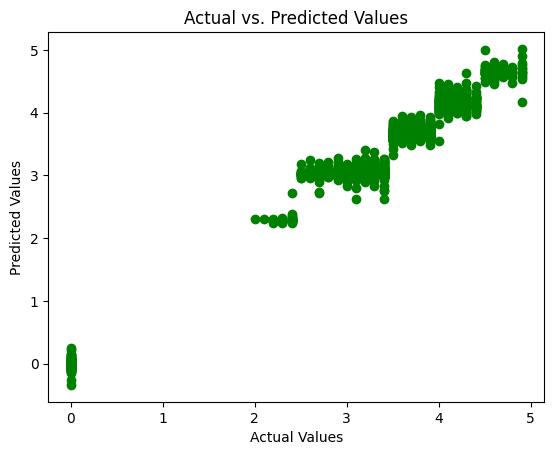

In [20]:
plt.scatter(y_test,y_pred,color='green')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

Predicting  the Restaurant Rating

In [21]:
x = pd.DataFrame({
    'City': ['Makati City'],
    'Cuisines': ['French, Japanese, Desserts'],
    'Has Table booking': ['Yes'],
    'Has Online delivery': ['No'],
    'Price range': [3],
    'Votes': [314],
    'Rating color': ['Dark Green'],
    'Average Cost for two':[600],
    'Rating text':['Excellent']
    
})
model.predict(x)

C:\Users\Ram\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


array([4.47139041])

this error because we while training data some column data re missed 
ex cuisene japan
in our input cusine japanese write so model did not found japanese in training 
its giving warning us 
this dont impact mostly but slittly